# CV-bias recovery: three-point $d_\omega$ scan

This notebook recovers the $M=10^6\,M_\odot$, $q=4$ injections with
$d_\tau=10^{-4}$ fixed and
$d_\omega\in\{10^{-2},10^{-3},10^{-4}\}$.

For each of the three injections it performs five Nelder–Mead alignment starts,
then computes the Cutler–Vallisneri bias with **one FTI parameter at a time**.

Only the requested recovery figures are produced:

- **11 figures**, one for each FTI parameter. Each figure contains the physical
  parameters plus that one active FTI parameter, with **all three deviation
  points shown together**.
- **1 final figure** containing all 11 active FTI-parameter biases, again with
  all three deviation points shown together.

No per-injection CV plots, waveform diagnostic plots, trend collages, or
displayed bias tables are produced.

## 0. Imports

In [1]:
import copy
import json
import math
import os

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from tqdm import tqdm

# Using MathText so that the plots do not require an external LaTeX installation
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["mathtext.fontset"] = "dejavusans"


In [2]:
import lisabeta.pyconstants as pyconstants
import lisabeta.tools.pytools as pytools
import lisabeta.lisa.pyresponse as pyresponse
import lisabeta.lisa.pyLISAnoise as pyLISAnoise
import lisabeta.lisa.lisatools as lisatools
import lisabeta.lisa.lisa as lisa
import lisabeta.lisa.lisa_fisher as lisa_fisher
import lisabeta.utils.plotutils as plotutils
import lisabeta.inference.inference as inference


/pbs/home/a/amahdi/lisabeta/src/lisabeta/waveforms/bbh/lalsim_wrap.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [3]:
%matplotlib inline

## 1. Plot labels and numerical utilities

Keeping the parameter names used internally by `lisabeta` unchanged while displaying mathematical labels (using latex) in the figures.


In [4]:
# Defining MathText labels without changing the parameter keys used in calculations

PARAM_LABELS_LATEX = {
    # Labeling the standard GR and source parameters
    "Mchirp": r"$\mathcal{M}$",
    "q": r"$q$",
    "chiPN": r"$\chi_{\rm PN}$",
    "chim": r"$\chi_{-}$",
    "Deltat": r"$\Delta t$",
    "dist": r"$d_L$",
    "inc": r"$\iota$",
    "phi": r"$\varphi_c$",
    "lambda": r"$\lambda$",
    "beta": r"$\beta$",
    "psi": r"$\psi$",

    # Displaying the internal FTI names as deviations of PN phase coefficients
    "fti_dchiMinus2v": r"$\delta\hat{\varphi}_{-2}$",
    "fti_dchi0v": r"$\delta\hat{\varphi}_{0}$",
    "fti_dchi1v": r"$\delta\hat{\varphi}_{1}$",
    "fti_dchi2v": r"$\delta\hat{\varphi}_{2}$",
    "fti_dchi3v": r"$\delta\hat{\varphi}_{3}$",
    "fti_dchi4v": r"$\delta\hat{\varphi}_{4}$",
    "fti_dchi5lv": r"$\delta\hat{\varphi}_{5\ell}$",
    "fti_dchi6v": r"$\delta\hat{\varphi}_{6}$",
    "fti_dchi6lv": r"$\delta\hat{\varphi}_{6\ell}$",
    "fti_dchi7v": r"$\delta\hat{\varphi}_{7}$",
    "fti_dkappa_S": r"$\delta\hat{\kappa}_{S}$",
    "fti_dxi0v": r"$\delta\hat{\xi}_{0}$",
}

CHANNEL_LABELS_LATEX = {
    "TDIA": r"$A$",
    "TDIE": r"$E$",
    "TDIT": r"$T$",
}


def latex_escape_text(text):
    """Escaping underscores for display inside MathText text blocks."""
    return str(text).replace("_", r"\_")


def latex_param_label(param):
    """Returning a MathText label and using roman text for unknown names."""
    return PARAM_LABELS_LATEX.get(param, rf"$\mathrm{{{latex_escape_text(param)}}}$")


def latex_param_labels(params):
    """Returning MathText labels for a sequence of parameter names."""
    return [latex_param_label(p) for p in params]


def latex_param_value(param, value):
    """Formatting a parameter label together with its numerical value."""
    label = latex_param_label(param)
    try:
        value_str = f"{float(value):g}"
    except (TypeError, ValueError):
        value_str = str(value)

    if label.startswith("$") and label.endswith("$"):
        return label[:-1] + rf"={value_str}$"

    return f"{label}={value_str}"


def latex_domega_dtau_label(d_omega=None, d_tau=None):
    """Formatting the injected frequency and damping-time deviations."""
    if d_omega is not None and d_tau is not None:
        try:
            d_omega_str = f"{float(d_omega):g}"
            d_tau_str = f"{float(d_tau):g}"
        except (TypeError, ValueError):
            d_omega_str = str(d_omega)
            d_tau_str = str(d_tau)

        if d_omega_str == d_tau_str:
            return rf"$\delta\Omega=\delta\tau={d_omega_str}$"
        return rf"$\delta\Omega={d_omega_str}$, $\delta\tau={d_tau_str}$"

    if d_omega is not None:
        try:
            d_omega_str = f"{float(d_omega):g}"
        except (TypeError, ValueError):
            d_omega_str = str(d_omega)
        return rf"$\delta\Omega={d_omega_str}$"

    if d_tau is not None:
        try:
            d_tau_str = f"{float(d_tau):g}"
        except (TypeError, ValueError):
            d_tau_str = str(d_tau)
        return rf"$\delta\tau={d_tau_str}$"

    return None


def latex_channel_label(chan):
    """Returning a compact MathText label for a TDI channel."""
    return CHANNEL_LABELS_LATEX.get(chan, rf"$\mathrm{{{latex_escape_text(chan)}}}$")


### Inner product and Fisher-bias calculation

Using the one-sided LISA noise PSD and the injection frequency grid consistently in the overlap, Fisher matrix, and systematic-bias integrals.


In [5]:
def overlap_AET_data(data1, data2, psd):
    """Calculating the summed TDI inner product on a nonuniform frequency grid."""
    freq = data1["freq"]
    diff_freq = np.diff(freq)
    tdi_keys = [key for key in data1 if key != "freq"]
    overlap = 0.0

    # Using the trapezoidal rule for every TDI channel contained in the data
    for channel in tdi_keys:
        integrand = (
            4.0
            * np.real(data1[channel] * np.conj(data2[channel]))
            / psd[channel]
        )
        overlap += np.sum(
            diff_freq * (integrand[1:] + integrand[:-1]) / 2.0
        )

    return overlap


In [6]:
def fisher_beta_data_grid_smbh(params, deltah_data, steps=None, list_params=lisa_fisher.default_list_fisher_params_smbh, list_fixed_params=[], Lframe=False, fLow_from_22=True, **waveform_params):
    """Here we compute the Fisher matrix and CV-bias vector on the data grid.

    Use the frequency samples and TDI channels contained in `deltah_data`
    for both quantities.
    """

    waveform_params = copy.deepcopy(waveform_params)

    # Setting the number of recovery parameters
    Npar = len(list_params)

    LISAnoise = waveform_params.get('LISAnoise', pyLISAnoise.LISAnoiseSciRDv1)
    TDI = waveform_params.get('TDI', 'TDIAET')
    if not TDI == 'TDIAET':
        raise ValueError('Data is using TDI channels among A,E,T, must have TDI=TDIAET or TDI2AET')
    TDIrescaled = waveform_params.get('TDIrescaled', True)
    LISAconst = waveform_params.get('LISAconst', pyresponse.LISAconstProposal)

    # Converting the input parameters to the requested sky frame
    if not params.get('Lframe', False) and Lframe:
        params_base = lisatools.convert_SSBframe_to_Lframe(
                            params,
                            t0=waveform_params['t0'],
                            frozenLISA=waveform_params['frozenLISA'])
    elif params.get('Lframe', False) and not Lframe:
        params_base = lisatools.convert_Lframe_to_SSBframe(
                            params,
                            t0=waveform_params['t0'],
                            frozenLISA=waveform_params['frozenLISA'])
    else:
        params_base = params.copy()

    # Complete the mass and spin parameterizations
    params_base = pytools.complete_mass_params(params_base)
    params_base = pytools.complete_spin_params(params_base)
    m1 = params_base['m1']
    m2 = params_base['m2']
    M = params_base['M']
    Ms = M * pyconstants.MTSUN_SI

    # Identifying the TDI channels and translating their internal names
    tdi_channels = [k for k in deltah_data.keys() if not k == 'freq']
    tdi_translate = {'TDIA': 'chan1', 'TDIE': 'chan2', 'TDIT': 'chan3'}
    channels = [tdi_translate[k] for k in tdi_channels]
    deltah = dict([(tdi_translate[k], deltah_data[k]) for k in tdi_channels])

    # Generating the base recovery waveform
    wftdi_base = lisa.GenerateLISATDI_SMBH(params_base, **waveform_params)

    # Reading the modes and their frequency bounds from the base waveform
    modes = wftdi_base['modes']
    fLow_lm = dict([(lm, wftdi_base[lm]['freq'][0]) for lm in modes])
    fHigh_lm = dict([(lm, wftdi_base[lm]['freq'][-1]) for lm in modes])
    if fLow_from_22:
        fLow = fLow_lm[(2, 2)]
    else:
        fLow = np.min([fLow_lm[lm] for lm in modes])
    fHigh = np.max([fHigh_lm[lm] for lm in modes])

    # Using the injection grid for both the Fisher matrix and bias vector
    freqs = np.asarray(deltah_data['freq'])
    df = np.diff(freqs)

    # Fixing the internal grid for every finite-difference waveform
    if modes == [(2, 2)]:
        gridfreq = wftdi_base[(2, 2)]['freq'].copy()
    else:
        gridfreq = dict([(lm, wftdi_base[lm]['freq'].copy()) for lm in modes])
    waveform_params['gridfreq'] = gridfreq

    tdifreqseries_base = lisa.GenerateLISATDIFreqseries_SMBH(params_base, freqs, **waveform_params)

    # Selecting two independent mass parameters and two spin parameters
    list_mass_params = [p for p in list_params if p in pytools.list_mass_params]
    list_spin_params = [p for p in list_params if p in pytools.list_spin_params]
    list_fixed_mass_params = [p for p in list_fixed_params if p in pytools.list_mass_params]
    list_fixed_spin_params = [p for p in list_fixed_params if p in pytools.list_spin_params]
    list_pair_mass_params = list_mass_params + list_fixed_mass_params
    list_pair_spin_params = list_spin_params + list_fixed_spin_params
    if (not len(list_mass_params) + len(list_fixed_mass_params) == 2) or (not len(list_spin_params) + len(list_fixed_spin_params) == 2):
        raise ValueError('list_params + list_fixed_params must have 2 mass and spin params.')
    if list_pair_mass_params == ['q', 'eta'] or list_pair_mass_params == ['eta', 'q']:
        raise ValueError('Mass params pair (q,eta) is fully degenerate.')

    # Removing redundant mass and spin parameterizations
    params_base_pair_massspin = params_base.copy()
    for p in pytools.list_mass_params:
        params_base_pair_massspin.pop(p, None)
    for p in pytools.list_spin_params:
        params_base_pair_massspin.pop(p, None)
    for p in list_pair_mass_params + list_pair_spin_params:
        params_base_pair_massspin[p] = params_base[p]

    # Evaluating the LISA noise on the injection grid
    noise_evaluator = pyLISAnoise.initialize_noise(
        LISAnoise,
        TDI=TDI,
        TDIrescaled=TDIrescaled,
        LISAconst=LISAconst,
    )
    Sn1_vals, Sn2_vals, Sn3_vals = pyLISAnoise.evaluate_noise(
        noise_evaluator,
        freqs,
        TDI=TDI,
        TDIrescaled=TDIrescaled,
        LISAconst=LISAconst,
    )
    Snvals = {'chan1': Sn1_vals, 'chan2': Sn2_vals, 'chan3': Sn3_vals}

    # Setting the mass-dependent finite-difference steps
    steps_default = lisa_fisher.get_default_steps_smbh(M)
    if steps is None:
        steps = steps_default
    else:
        steps_tmp = copy.deepcopy(steps_default)
        steps_tmp.update(steps)
        steps = steps_tmp

    # Generating the finite-difference waveforms
    dh = {}
    for p in list_params:
        frac = lisa_fisher.dict_params_fractional[p]
        params_step = params_base_pair_massspin.copy()
        if frac:
            params_step[p] *= 1 + steps[p]
        else:
            params_step[p] += steps[p]
        params_step = pytools.complete_mass_params(params_step)
        params_step = pytools.complete_spin_params(params_step)

        tdifreqseries_step = lisa.GenerateLISATDIFreqseries_SMBH(params_step, freqs, **waveform_params)

        # Calculating the signal derivative for each TDI channel
        dh[p] = {}
        for chan in channels:
            dh[p][chan] = np.zeros_like(freqs, dtype=complex)
            for lm in modes:
                dh[p][chan] += (tdifreqseries_step[lm][chan] - tdifreqseries_base[lm][chan]) / steps[p]

    # Calculating beta_i on the injection grid
    beta = np.zeros(Npar, dtype=float)
    for i in range(Npar):
        pi = list_params[i]
        for chan in channels:
            integrand = np.real(dh[pi][chan] * np.conj(deltah[chan]) / Snvals[chan])
            beta[i] += 4 * np.sum(df * integrand[:-1])

    # Calculating Gamma_ij on the same grid and TDI channels
    fisher = np.zeros((Npar, Npar), dtype=float)
    for i in range(Npar):
        pi = list_params[i]
        for j in range(i, Npar):
            pj = list_params[j]
            val = 0.0
            for chan in channels:
                integrand = np.real(dh[pi][chan] * np.conj(dh[pj][chan]) / Snvals[chan])
                val += 4 * np.sum(df * integrand[:-1])
            fisher[i, j] = val
            fisher[j, i] = val

    # Restoring the physical scaling of parameters varied fractionally
    scales = np.ones(len(list_params))
    for i, p in enumerate(list_params):
        if lisa_fisher.dict_params_fractional[p]:
            scales[i] = 1.0 / params_base[p]
    scales_diag = np.diag(scales)

    beta = np.dot(scales_diag, beta)
    fisher = np.dot(scales_diag, np.dot(fisher, scales_diag))
    fisher = 0.5 * (fisher + fisher.T)

    try:
        cov = np.linalg.inv(fisher)
        covariance_method = 'inv'
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(fisher, rcond=1e-12)
        covariance_method = 'pinv'

    fishercov = {
        'fisher': fisher,
        'cov': cov,
        'list_params': list(list_params),
        'channels': list(tdi_channels),
        'n_freq': len(freqs),
        'freq_min': float(np.min(freqs)),
        'freq_max': float(np.max(freqs)),
        'freq_grid_source': 'deltah_data["freq"]',
        'covariance_method': covariance_method,
    }

    return fishercov, beta


In [7]:
def format_mass_title(mass_value, use_latex=True):
    """Formatting a numerical total mass for figure titles."""
    mass_value = float(mass_value)
    exponent = int(np.floor(np.log10(mass_value)))
    mantissa = mass_value / (10.0 ** exponent)

    if np.isclose(mantissa, 1.0):
        if use_latex:
            return rf"$M=10^{{{exponent}}}\,M_{{\odot}}$"
        return f"1e{exponent} Msun"

    if use_latex:
        return rf"$M={mantissa:g}\times10^{{{exponent}}}\,M_{{\odot}}$"
    return f"{mantissa:g}e{exponent} Msun"


## 2. Single-mass FTI recovery configuration

Matching the injection notebook’s existing tag, mass label, three deviation IDs, waveform modes, and output structure before starting the recovery calculation.


In [8]:
# Matching the tag used by the single-mass injection notebook
deviation_tag = "dtau_fixed_0p01_domega_scan_M1e6_q4_3points"

Syst_dir = os.path.expanduser(
    "/pbs/home/a/amahdi/pySEOBNR_deviation_2/Data"
)
Input_scan_dir = os.path.join(Syst_dir, "pSEOB_" + deviation_tag)
Run_dir = os.path.join(
    Syst_dir,
    "SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_"
    + deviation_tag,
)

# Setting the same mass array and labels used during injection generation
MASS_VALUES = np.array([1e6], dtype=float)
MASS_LABELS = ["M1e6"]
MASS_VALUE_BY_LABEL = dict(zip(MASS_LABELS, MASS_VALUES))
MASS_TITLE_BY_LABEL = {
    label: format_mass_title(value)
    for value, label in zip(MASS_VALUES, MASS_LABELS)
}

SCAN_PARAMETER = "d_omega"
FIXED_PARAMETER = "d_tau"
FIXED_VALUE = 0.0001
SCAN_LABEL = r"$d_\omega$"
FIXED_LABEL = r"$d_\tau=0.0001$"
expected_deviation_values = np.array([0.01, 0.001, 0.0001], dtype=float)
inj_ids = list(range(len(expected_deviation_values)))
MASS_RATIO = 4.0
expected_domega_values = expected_deviation_values.copy()
expected_dtau_values = np.full(len(inj_ids), FIXED_VALUE)

wf_rec = "SEOB"
if wf_rec == "SEOB":
    wf_name = "SEOBNRv5HMROM"
elif wf_rec == "XHM":
    wf_name = "PhenomXHM"
else:
    raise ValueError(f"Unknown wf_rec = {wf_rec}")

output_tag = "rom_pseob_ratio_phase_" + deviation_tag
RECOVERY_ROOT = os.path.join(Run_dir, "run_data", "bias_syst_recovery")
os.makedirs(RECOVERY_ROOT, exist_ok=True)

# Locate and validate one parameter file for each mass
PARAMS_FILES = {}
for mass_value, mass_label in zip(MASS_VALUES, MASS_LABELS):
    params_filename = (
        "params_injection_set_" + deviation_tag + "_" + mass_label + ".h5"
    )
    candidates = [
        os.path.join(Run_dir, params_filename),
        os.path.join(Input_scan_dir, params_filename),
    ]

    params_file = next(
        (candidate for candidate in candidates if os.path.exists(candidate)),
        None,
    )
    if params_file is None:
        raise FileNotFoundError(
            f"No parameter file was found for {mass_label}.\n"
            + "\n".join(candidates)
            + "\nRun the single-mass injection notebook first."
        )

    with h5py.File(params_file, "r") as hf:
        if "M" not in hf or len(hf["M"]) != len(inj_ids):
            raise ValueError(
                f"The parameter file for {mass_label} does not contain "
                f"the required {len(inj_ids)} rows: {params_file}"
            )

        stored_masses = np.asarray(hf["M"][:len(inj_ids)], dtype=float)
        if not np.allclose(stored_masses, mass_value):
            raise ValueError(
                f"Mass mismatch in {params_file}: expected {mass_value}, "
                f"found {stored_masses}."
            )

        for key in ("q", "d_omega", "d_tau"):
            if key not in hf or hf[key].shape != (len(inj_ids),):
                raise ValueError(f"Missing or incorrect {key} grid in {params_file}")
        if not np.allclose(hf["q"][:], MASS_RATIO, rtol=1e-12, atol=0.0):
            raise ValueError(f"Expected q={MASS_RATIO} in {params_file}")

        if "d_omega" in hf:
            stored_domega = np.asarray(
                hf["d_omega"][:len(inj_ids)],
                dtype=float,
            )
            if not np.allclose(stored_domega, expected_domega_values, rtol=1e-12, atol=0.0):
                raise ValueError(
                    f"d_omega values do not match the three-row scan in "
                    f"{params_file}."
                )

        if "d_tau" in hf:
            stored_dtau = np.asarray(
                hf["d_tau"][:len(inj_ids)],
                dtype=float,
            )
            if not np.allclose(stored_dtau, expected_dtau_values, rtol=1e-12, atol=0.0):
                raise ValueError(
                    f"d_tau values do not match the three-row scan in "
                    f"{params_file}."
                )

    PARAMS_FILES[mass_label] = params_file
    os.makedirs(os.path.join(RECOVERY_ROOT, mass_label), exist_ok=True)

generation_manifest = os.path.join(
    Run_dir,
    f"generation_manifest_{deviation_tag}.json",
)

print("Run_dir:", Run_dir)
print("Recovery root:", RECOVERY_ROOT)
print("Mass folders:", MASS_LABELS)
print("Injection IDs:", inj_ids)
print("Parameter files:")
for mass_label, params_file in PARAMS_FILES.items():
    print(f"  {mass_label}: {params_file}")
print("Generation manifest exists?", os.path.exists(generation_manifest))


Run_dir: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points
Recovery root: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery
Mass folders: ['M1e6']
Injection IDs: [0, 1, 2]
Parameter files:
  M1e6: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/params_injection_set_dtau_fixed_0p01_domega_scan_M1e6_q4_3points_M1e6.h5
Generation manifest exists? True


In [9]:
# Setting the recovery waveform and LISA response
waveform_params_base_recovery = {
    "minf": 1e-5,
    "maxf": 0.5,
    "t0": 0.0,
    "timetomerger_max": 1.0,
    "fend": None,
    "tmin": None,
    "tmax": None,
    "phiref": 0.0,
    "fref_for_phiref": 0.0,
    "tref": 0.0,
    "fref_for_tref": 0.0,
    "force_phiref_fref": True,
    "toffset": 0.0,
    "modes": [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)],
    "TDI": "TDIAET",
    "acc": 0.0001,
    "order_fresnel_stencil": 0,
    "approximant": "SEOBNRv5HMROM",
    "LISAconst": "Proposal",
    "responseapprox": "full",
    "frozenLISA": False,
    "TDIrescaled": True,
    "LISAnoise": {
        "InstrumentalNoise": "SciRDv1",
        "WDbackground": True,
        "WDduration": 4.0,
        "lowf_add_pm_noise_f0": 0.0,
        "lowf_add_pm_noise_alpha": 2.0,
    },
}

BASE_GR_PARAM = [
    "Mchirp", "q", "chiPN", "chim", "Deltat",
    "dist", "inc", "phi", "lambda", "beta", "psi",
]
alignment_param = ["Deltat", "phi", "psi"]

# Activating exactly 11 FTI parameters, one at a time, during the Fisher calculation
FTI_PARAMS_TO_SCAN = [
    "fti_dchiMinus2v",
    "fti_dchi0v",
    "fti_dchi1v",
    "fti_dchi2v",
    "fti_dchi3v",
    "fti_dchi4v",
    "fti_dchi5lv",
    "fti_dchi6v",
    "fti_dchi6lv",
    "fti_dchi7v",
    "fti_dkappa_S",
]

# Keep every FTI recovery value at zero for the GR-template bias test
FTI_PARAM_VALUES = {param: 0.0 for param in FTI_PARAMS_TO_SCAN}

Ntries = 5  # Exactly five optimization runs for each QNM deviation pair
Deltat_max = 200.0

print("Recovery approximant:", waveform_params_base_recovery["approximant"])
print("Base GR parameters:", BASE_GR_PARAM)
print("FTI parameters scanned one at a time:", FTI_PARAMS_TO_SCAN)


Recovery approximant: SEOBNRv5HMROM
Base GR parameters: ['Mchirp', 'q', 'chiPN', 'chim', 'Deltat', 'dist', 'inc', 'phi', 'lambda', 'beta', 'psi']
FTI parameters scanned one at a time: ['fti_dchiMinus2v', 'fti_dchi0v', 'fti_dchi1v', 'fti_dchi2v', 'fti_dchi3v', 'fti_dchi4v', 'fti_dchi5lv', 'fti_dchi6v', 'fti_dchi6lv', 'fti_dchi7v', 'fti_dkappa_S']


In [10]:
def get_mass_run_data_dir(mass_label):
    """Returning the recovery output directory for one mass."""
    return os.path.join(RECOVERY_ROOT, mass_label)


def get_injection_data_file(mass_label, inj_id):
    """Returning the summed multiplier-injection file for one mass and ID."""
    return os.path.join(
        Run_dir,
        mass_label,
        "data_" + output_tag + "_" + mass_label + "_id_" + str(inj_id) + ".h5"
    )


def get_injection_datalm_file(mass_label, inj_id):
    """Returning the mode-resolved injection file for one mass and ID."""
    return os.path.join(
        Run_dir,
        mass_label,
        "datalm_" + output_tag + "_" + mass_label + "_id_" + str(inj_id) + ".h5"
    )


def get_multiplier_file(mass_label, inj_id):
    """Returning the pSEOB multiplier file for one mass and ID."""
    return os.path.join(
        Run_dir,
        mass_label,
        "multiplier_pseob_ratio_phase_" + deviation_tag + "_" + mass_label + "_id_" + str(inj_id) + ".h5"
    )


def load_ratio_wrapper_injection(mass_label, inj_id, params_file=None):
    """Loading one mass-specific multiplier injection and its parameters."""
    if params_file is None:
        params_file = PARAMS_FILES[mass_label]

    data_file = get_injection_data_file(mass_label, inj_id)
    datalm_file = get_injection_datalm_file(mass_label, inj_id)
    multiplier_file = get_multiplier_file(mass_label, inj_id)

    if not os.path.exists(params_file):
        raise FileNotFoundError(f"Missing params_file: {params_file}")
    if not os.path.exists(data_file):
        raise FileNotFoundError(f"Missing ratio-wrapper data_file for inj_id={inj_id}: {data_file}")

    print("Loading ratio-wrapper injection data from:")
    print(data_file)
    print("Mode-by-mode datalm file exists?", os.path.exists(datalm_file), datalm_file)
    print("Multiplier file exists?", os.path.exists(multiplier_file), multiplier_file)

    with h5py.File(params_file, 'r') as hf:
        params = {
            'M': float(hf['M'][inj_id]),
            'q': float(hf['q'][inj_id]),
            'chi1': float(hf['chi1'][inj_id]),
            'chi2': float(hf['chi2'][inj_id]),
            'dist': float(hf['dist'][inj_id]),
            'inc': float(hf['inc'][inj_id]),
            'phi': float(hf['phi'][inj_id]),
            'lambda': float(hf['lambda'][inj_id]),
            'beta': float(hf['beta'][inj_id]),
            'psi': float(hf['psi'][inj_id]),
            'Deltat': float(hf['Deltat'][inj_id]),
            'Lframe': bool(hf['Lframe'][:][0]),
        }

        # Keeping the injected deviations as labels for plots and checks
        if 'd_omega' in hf:
            params['d_omega'] = float(hf['d_omega'][inj_id])
        if 'd_tau' in hf:
            params['d_tau'] = float(hf['d_tau'][inj_id])

    print("Loaded parameter labels:")
    print("  d_omega =", params.get('d_omega', None))
    print("  d_tau   =", params.get('d_tau', None))

    tdidata = inference.load_data_TDIAET(data_file)
    return params, tdidata


def make_fti_recovery_inputs(params0, fti_param, fti_value=0.0):
    params = params0.copy()

    # Removing deviation labels before generating the ROM recovery template
    params.pop('d_omega', None)
    params.pop('d_tau', None)

    # Removing every FTI key because lisabeta checks key presence
    for p in FTI_PARAMS_TO_SCAN:
        params.pop(p, None)

    # Adding only the active FTI parameter for the current case
    params[fti_param] = fti_value

    params_complete_mass = pytools.complete_mass_params(params)

    waveform_params_local = copy.deepcopy(waveform_params_base_recovery)
    waveform_params_local.pop("tgr_params", None)

    waveform_params_local["tgr_params"] = {
        "FTI": {
            "fti_params": [fti_param],
            "Mchirp_inj": params_complete_mass["Mchirp"],
            "dxi0v_inj": 0.0
        }
    }

    list_params = BASE_GR_PARAM + [fti_param]

    return params, waveform_params_local, list_params


def build_recovery_tdi_on_injection_grid(injection_align, tdidata, waveform_params):
    """Generating the ROM recovery template on the injection frequency grid."""
    freq_grid = tdidata['freq']
    tdifreqseries = lisa.GenerateLISATDIFreqseries_SMBH(injection_align, freq_grid, **waveform_params)

    tdi_align = {
        'freq': freq_grid.copy(),
        'TDIA': np.zeros(len(freq_grid), dtype=complex),
        'TDIE': np.zeros(len(freq_grid), dtype=complex),
        'TDIT': np.zeros(len(freq_grid), dtype=complex),
    }

    for lm in tdifreqseries['modes']:
        tdi_align['TDIA'] += tdifreqseries[lm]['chan1']
        tdi_align['TDIE'] += tdifreqseries[lm]['chan2']
        tdi_align['TDIT'] += tdifreqseries[lm]['chan3']

    return tdi_align


def process_nelder_mead_result(best_x, Deltat_max=200.0):
    # Convert the scaled optimizer variables back to physical parameters
    deltat_true = best_x[0] * Deltat_max
    phi_true = (best_x[1] + np.pi) % (2 * np.pi) - np.pi
    psi_true = best_x[2] % np.pi
    return {
        'Deltat': deltat_true,
        'phi': phi_true,
        'psi': psi_true,
    }


def run_nelder_mead_alignment(params, tdidata, waveform_params, Ntries=5, Deltat_max=200.0, seed=None):
    # Run the direct Nelder-Mead likelihood maximization
    if seed is not None:
        rng = np.random.default_rng(seed)
        Deltat_tries = rng.uniform(-Deltat_max, Deltat_max, size=Ntries)
        phi_tries = rng.uniform(-np.pi, np.pi, size=Ntries)
        psi_tries = rng.uniform(0.0, np.pi, size=Ntries)
    else:
        Deltat_tries = np.random.uniform(-Deltat_max, Deltat_max, size=Ntries)
        phi_tries = np.random.uniform(-np.pi, np.pi, size=Ntries)
        psi_tries = np.random.uniform(0.0, np.pi, size=Ntries)

    likelihood = lisa.LikelihoodLISASMBH_Data(params, data=tdidata, **waveform_params)

    def f_opt(x):
        params_NM = params.copy()
        params_NM['Deltat'] = Deltat_max * x[0]
        params_NM['phi'] = x[1]
        params_NM['psi'] = x[2]

        if np.abs(x[0]) > 1.0:
            return np.inf
        return -likelihood.lnL(params_NM, ngrid=128, **waveform_params)

    scale = 0.5
    res_neldermead = {}

    for j in tqdm(range(Ntries), desc='Nelder-Mead starts', leave=False):
        x0 = np.array([Deltat_tries[j] / Deltat_max, phi_tries[j], psi_tries[j]])
        initial_simplex = np.array([
            x0,
            x0 + scale * np.array([1, 0, 0]),
            x0 + scale * np.array([0, 1, 0]),
            x0 + scale * np.array([0, 0, 1]),
        ])
        res_neldermead[j] = scipy.optimize.minimize(
            f_opt,
            x0,
            method='Nelder-Mead',
            options={'initial_simplex': initial_simplex, 'return_all': True},
        )

    finite_trials = {k: res for k, res in res_neldermead.items()
                     if np.isfinite(res.fun) and np.all(np.isfinite(res.x))}
    if not finite_trials:
        raise RuntimeError("All five alignment runs returned nonfinite results.")
    best_j = min(finite_trials, key=lambda k: finite_trials[k].fun)
    best_result = res_neldermead[best_j]
    if not best_result.success:
        print("WARNING: best alignment did not converge:", best_result.message)
    ML_values = process_nelder_mead_result(np.array(best_result.x), Deltat_max=Deltat_max)

    return best_j, best_result, ML_values, res_neldermead


def compute_match_mismatch(tdidata, tdi_align, waveform_params):
    # Calculating the TDI overlap, match, and mismatch
    freq_grid = tdidata['freq']
    lisa_psd = pyLISAnoise.evaluate_AET_psd(freq_grid, TDIT=True, **waveform_params)

    overlap_12 = overlap_AET_data(tdidata, tdi_align, lisa_psd)
    overlap_11 = overlap_AET_data(tdidata, tdidata, lisa_psd)
    overlap_22 = overlap_AET_data(tdi_align, tdi_align, lisa_psd)

    norm_factor = np.sqrt(overlap_11) * np.sqrt(overlap_22)
    match = np.abs(overlap_12) / norm_factor
    mismatch = 1.0 - match

    return match, mismatch, lisa_psd


def save_recovery_arrays(case_dir, mass_label, inj_id, fti_param, tdidata, tdi_align, residual_align):
    # Saving the recovery template and residual arrays for later inspection
    os.makedirs(case_dir, exist_ok=True)
    out_file = os.path.join(case_dir, f'recovery_arrays_{fti_param}_{mass_label}_id_{inj_id}.h5')
    with h5py.File(out_file, 'w') as hf:
        hf.attrs['fti_param'] = fti_param
        hf.attrs['inj_id'] = inj_id
        hf.attrs['mass_label'] = mass_label
        hf.attrs['M'] = float(MASS_VALUE_BY_LABEL[mass_label])
        hf.create_dataset('freq', data=tdidata['freq'])
        for chan in ['TDIA', 'TDIE']:
            hf.create_dataset('injection_' + chan, data=tdidata[chan])
            hf.create_dataset('template_' + chan, data=tdi_align[chan])
            hf.create_dataset('residual_' + chan, data=residual_align[chan])
        if 'TDIT' in tdi_align:
            hf.create_dataset('template_TDIT', data=tdi_align['TDIT'])
    return out_file


In [11]:
# Check every mass-specific injection path before starting the expensive scan
print("Run_dir used by this notebook:", Run_dir)
print("Run_dir exists?", os.path.exists(Run_dir))

missing_injection_files = []
for mass_label in MASS_LABELS:
    print("\n" + "=" * 80)
    print(f"Checking {mass_label}")
    print("Parameter file:", PARAMS_FILES[mass_label])

    for inj_id in inj_ids:
        data_file = get_injection_data_file(mass_label, inj_id)
        datalm_file = get_injection_datalm_file(mass_label, inj_id)
        multiplier_file = get_multiplier_file(mass_label, inj_id)

        print(f"inj_id={inj_id}:")
        print("  data exists?      ", os.path.exists(data_file), data_file)
        print("  datalm exists?    ", os.path.exists(datalm_file), datalm_file)
        print("  multiplier exists?", os.path.exists(multiplier_file), multiplier_file)

        for file_path in (data_file, datalm_file, multiplier_file):
            if not os.path.exists(file_path):
                missing_injection_files.append(file_path)

if missing_injection_files:
    preview = "\n".join(missing_injection_files[:10])
    raise FileNotFoundError(
        f"Missing {len(missing_injection_files)} injection files.\n"
        f"First missing paths:\n{preview}\n"
        "Run the complete single-mass injection notebook first."
    )


Run_dir used by this notebook: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points
Run_dir exists? True

Checking M1e6
Parameter file: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/params_injection_set_dtau_fixed_0p01_domega_scan_M1e6_q4_3points_M1e6.h5
inj_id=0:
  data exists?       True /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/M1e6/data_rom_pseob_ratio_phase_dtau_fixed_0p01_domega_scan_M1e6_q4_3points_M1e6_id_0.h5
  datalm exists?     True /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/M1e6/datalm_rom_pseob_ratio_phase_dtau_fixed_0p01_domega_scan_M1e6_q4_3points_M1e6_id_0.h5
  multipli

In [12]:
# Running five Nelder-Mead starts per QNM deviation pair, followed by the FTI scan
all_results = {mass_label: {} for mass_label in MASS_LABELS}
alignment_results = {mass_label: {} for mass_label in MASS_LABELS}

# Using reproducible but mass-dependent alignment starts
seed_alignment = 1234
reference_fti_param = FTI_PARAMS_TO_SCAN[0]

for mass_index, (mass_value, mass_label) in enumerate(
    zip(MASS_VALUES, MASS_LABELS)
):
    mass_run_data_dir = get_mass_run_data_dir(mass_label)
    os.makedirs(mass_run_data_dir, exist_ok=True)

    print("\n" + "#" * 90)
    print(f"STARTING MASS: {mass_label} ({mass_value:.6e} Msun)")
    print("#" * 90)

    for inj_id in inj_ids:
        all_results[mass_label][inj_id] = {}

        print("\n" + "#" * 90)
        print(f"STARTING {mass_label}, inj_id={inj_id}")
        print("#" * 90)

        # Loading the current injection only once
        params0, tdidata = load_ratio_wrapper_injection(
            mass_label=mass_label,
            inj_id=inj_id,
        )

        if not np.isclose(params0["M"], mass_value):
            raise ValueError(
                f"Loaded mass mismatch for {mass_label}, inj_id={inj_id}: "
                f"expected {mass_value}, found {params0['M']}"
            )

        # Building one GR recovery setup for the alignment
        params_ref, waveform_params_ref, list_params_ref = (
            make_fti_recovery_inputs(
                params0,
                reference_fti_param,
                fti_value=0.0,
            )
        )

        print("\n" + "=" * 80)
        print(f"Running {Ntries} Nelder-Mead starts for {mass_label}, inj_id={inj_id}")
        print(f"Reference FTI parameter: {reference_fti_param}")

        seed_local = None
        if seed_alignment is not None:
            seed_local = (
                seed_alignment
                + 100_000 * mass_index
                + 1_000 * int(inj_id)
            )

        best_j, best_result, ML_values, res_neldermead = (
            run_nelder_mead_alignment(
                params_ref,
                tdidata,
                waveform_params_ref,
                Ntries=Ntries,
                Deltat_max=Deltat_max,
                seed=seed_local,
            )
        )

        print(f"Best trial: {best_j}")
        print(f"Minimum value (-lnL): {best_result.fun}")
        print("Best alignment values:", ML_values)

        # Building the aligned GR waveform and residual once
        injection_align_ref = params_ref.copy()
        for param in alignment_param:
            injection_align_ref[param] = ML_values[param]

        tdi_align = build_recovery_tdi_on_injection_grid(
            injection_align_ref,
            tdidata,
            waveform_params_ref,
        )

        residual_align = {"freq": tdidata["freq"]}
        for channel in ("TDIA", "TDIE"):
            residual_align[channel] = tdi_align[channel] - tdidata[channel]

        match, mismatch, lisa_psd = compute_match_mismatch(
            tdidata,
            tdi_align,
            waveform_params_ref,
        )

        print(f"Match: {match:.10f}")
        print(f"Mismatch: {mismatch:.10e}")

        alignment_results[mass_label][inj_id] = {
            "mass_label": mass_label,
            "M": float(mass_value),
            "mass_name": MASS_TITLE_BY_LABEL[mass_label],
            "inj_id": inj_id,
            "d_omega": params0.get("d_omega"),
            "d_tau": params0.get("d_tau"),
            "params0": params0,
            "tdidata": tdidata,
            "reference_fti_param": reference_fti_param,
            "reference_params": params_ref,
            "reference_waveform_params": waveform_params_ref,
            "best_j": best_j,
            "best_result": best_result,
            "ML_values": ML_values,
            "injection_align_ref": injection_align_ref,
            "tdi_align": tdi_align,
            "residual_align": residual_align,
            "match": match,
            "mismatch": mismatch,
            "lisa_psd": lisa_psd,
            "res_neldermead": res_neldermead,
        }

        # Reusing the aligned residual while changing only the active FTI parameter
        for fti_param in FTI_PARAMS_TO_SCAN:
            fti_value = FTI_PARAM_VALUES.get(fti_param, 0.0)

            params, waveform_params, list_params = make_fti_recovery_inputs(
                params0,
                fti_param,
                fti_value=fti_value,
            )

            print("\n" + "=" * 80)
            print(f"Mass: {mass_label}, inj_id={inj_id}")
            print(f"FTI CV-bias case: {fti_param}={fti_value}")
            print("Using the already aligned residual.")

            injection_align = params.copy()
            for param in alignment_param:
                injection_align[param] = ML_values[param]

            injection_align_complete = pytools.complete_mass_params(
                injection_align.copy()
            )

            fishercov, beta_vec = fisher_beta_data_grid_smbh(
                injection_align_complete,
                residual_align,
                list_params=list_params,
                Lframe=True,
                **waveform_params,
            )

            deltatheta = np.dot(fishercov["cov"], -beta_vec)
            scales = {
                param: np.sqrt(fishercov["cov"][index, index])
                for index, param in enumerate(list_params)
            }
            cv_bias_sigma = {
                param: deltatheta[index] / scales[param]
                for index, param in enumerate(list_params)
            }

            case_dir = os.path.join(
                mass_run_data_dir,
                f"id_{inj_id}",
                fti_param,
            )
            arrays_file = save_recovery_arrays(
                case_dir,
                mass_label,
                inj_id,
                fti_param,
                tdidata,
                tdi_align,
                residual_align,
            )

            i_fti = list_params.index(fti_param)
            print("Recovered CV bias in FTI:", deltatheta[i_fti])
            print("Recovered in sigma units:", cv_bias_sigma[fti_param])
            print("Saved arrays:", arrays_file)

            all_results[mass_label][inj_id][fti_param] = {
                "mass_label": mass_label,
                "M": float(mass_value),
                "mass_name": MASS_TITLE_BY_LABEL[mass_label],
                "inj_id": inj_id,
                "d_omega": params0.get("d_omega"),
                "d_tau": params0.get("d_tau"),
                "fti_param": fti_param,
                "fti_value": fti_value,
                "list_params": list_params,
                "params": params,
                "tdidata": tdidata,
                "waveform_params": waveform_params,
                "best_j": best_j,
                "best_result": best_result,
                "ML_values": ML_values,
                "injection_align": injection_align,
                "res_neldermead": res_neldermead,
                "tdi_align": tdi_align,
                "residual_align": residual_align,
                "match": match,
                "mismatch": mismatch,
                "lisa_psd": lisa_psd,
                "beta": beta_vec,
                "fishercov": fishercov,
                "deltatheta": deltatheta,
                "scales": scales,
                "cv_bias_sigma": cv_bias_sigma,
                "arrays_file": arrays_file,
            }

print("Finished masses:", list(all_results.keys()))
for mass_label, results_by_inj in all_results.items():
    print(f"{mass_label}: finished injection IDs:", list(results_by_inj.keys()))



##########################################################################################
STARTING MASS: M1e6 (1.000000e+06 Msun)
##########################################################################################

##########################################################################################
STARTING M1e6, inj_id=0
##########################################################################################
Loading ratio-wrapper injection data from:
/pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/M1e6/data_rom_pseob_ratio_phase_dtau_fixed_0p01_domega_scan_M1e6_q4_3points_M1e6_id_0.h5
Mode-by-mode datalm file exists? True /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/M1e6/datalm_rom_pseob_ratio_phase_dtau_fixed_0p01_domega_scan_M1e6_q4_3points_M1e6_id_0.h5
Multiplier fi

Best trial: 0
Minimum value (-lnL): 175.1514435751427
Best alignment values: {'Deltat': np.float64(-0.19393148130230384), 'phi': np.float64(0.7035469182274574), 'psi': np.float64(1.2008883905558274)}
Match: 0.9999008393
Mismatch: 9.9160697194e-05

Mass: M1e6, inj_id=0
FTI CV-bias case: fti_dchiMinus2v=0.0
Using the already aligned residual.
Recovered CV bias in FTI: 7.518604689023939e-07
Recovered in sigma units: 0.6815035662242255
Saved arrays: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/id_0/fti_dchiMinus2v/recovery_arrays_fti_dchiMinus2v_M1e6_id_0.h5

Mass: M1e6, inj_id=0
FTI CV-bias case: fti_dchi0v=0.0
Using the already aligned residual.
Recovered CV bias in FTI: 0.00038975733507283505
Recovered in sigma units: 0.849202995270229
Saved arrays: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_d

Best trial: 1
Minimum value (-lnL): 1.763093630116122
Best alignment values: {'Deltat': np.float64(-0.027321733871217904), 'phi': np.float64(0.7003573172975313), 'psi': np.float64(1.2000925861494134)}
Match: 0.9999461089
Mismatch: 5.3891149168e-05

Mass: M1e6, inj_id=1
FTI CV-bias case: fti_dchiMinus2v=0.0
Using the already aligned residual.
Recovered CV bias in FTI: 8.73205730213198e-08
Recovered in sigma units: 0.07913994719557457
Saved arrays: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/id_1/fti_dchiMinus2v/recovery_arrays_fti_dchiMinus2v_M1e6_id_1.h5

Mass: M1e6, inj_id=1
FTI CV-bias case: fti_dchi0v=0.0
Using the already aligned residual.
Recovered CV bias in FTI: 3.384643330102367e-05
Recovered in sigma units: 0.07372678904936121
Saved arrays: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition

Best trial: 4
Minimum value (-lnL): 0.018525136594498014
Best alignment values: {'Deltat': np.float64(-0.01074755641284268), 'phi': np.float64(0.7000382497852393), 'psi': np.float64(1.200008406079613)}
Match: 0.9999465617
Mismatch: 5.3438251731e-05

Mass: M1e6, inj_id=2
FTI CV-bias case: fti_dchiMinus2v=0.0
Using the already aligned residual.
Recovered CV bias in FTI: 1.4025845073730039e-08
Recovered in sigma units: 0.012711677251825149
Saved arrays: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/id_2/fti_dchiMinus2v/recovery_arrays_fti_dchiMinus2v_M1e6_id_2.h5

Mass: M1e6, inj_id=2
FTI CV-bias case: fti_dchi0v=0.0
Using the already aligned residual.
Recovered CV bias in FTI: 1.4491743710198942e-06
Recovered in sigma units: 0.0031566239028369292
Saved arrays: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_co

## CV-bias figures

The recovery calculation above has produced one result for each combination of
three QNM-deviation injections and eleven FTI parameters.

The plotting below is deliberately minimal. For every active FTI parameter,
one figure shows the biases of the physical parameters and that FTI parameter.
The three injection values are placed side by side at every parameter location,
so none of the three points can hide behind another.

In [13]:

# Plotting configuration: exactly three deviation points in every parameter group
plot_deviation_values = np.array(sorted(expected_deviation_values), dtype=float)

if len(plot_deviation_values) != 3:
    raise ValueError(
        f"This notebook is designed for exactly three deviation values; "
        f"found {len(plot_deviation_values)}."
    )

PLOT_NORM = mpl.colors.LogNorm(
    vmin=float(plot_deviation_values.min()),
    vmax=float(plot_deviation_values.max()),
)
PLOT_CMAP = mpl.cm.coolwarm
POINT_OFFSETS = np.array([-0.20, 0.0, 0.20])

def scan_value_label(value):
    if SCAN_PARAMETER == "d_tau":
        return rf"$d_\tau={value:g}$"
    if SCAN_PARAMETER == "d_omega":
        return rf"$d_\omega={value:g}$"
    return f"{SCAN_PARAMETER}={value:g}"

def three_results_for_fti(results_by_inj, fti_param):
    """Return the three injection results ordered by the varying QNM deviation."""
    ordered = []
    for value in plot_deviation_values:
        matching = []
        for inj_id in inj_ids:
            result = results_by_inj.get(inj_id, {}).get(fti_param)
            if result is None:
                continue
            stored_value = float(result[SCAN_PARAMETER])
            if np.isclose(stored_value, value, rtol=1e-12, atol=0.0):
                matching.append((inj_id, result))

        if len(matching) != 1:
            raise RuntimeError(
                f"For {fti_param}, expected exactly one recovery result at "
                f"{SCAN_PARAMETER}={value:g}, found {len(matching)}."
            )
        ordered.append((value, matching[0][0], matching[0][1]))

    if len(ordered) != 3:
        raise RuntimeError(
            f"For {fti_param}, expected three deviation results, found {len(ordered)}."
        )
    return ordered

def save_figure(fig, output_dir, basename):
    os.makedirs(output_dir, exist_ok=True)
    png = os.path.join(output_dir, basename + ".png")
    pdf = os.path.join(output_dir, basename + ".pdf")
    fig.savefig(png, dpi=220, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", pdf)


Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchiMinus2v.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchiMinus2v.pdf


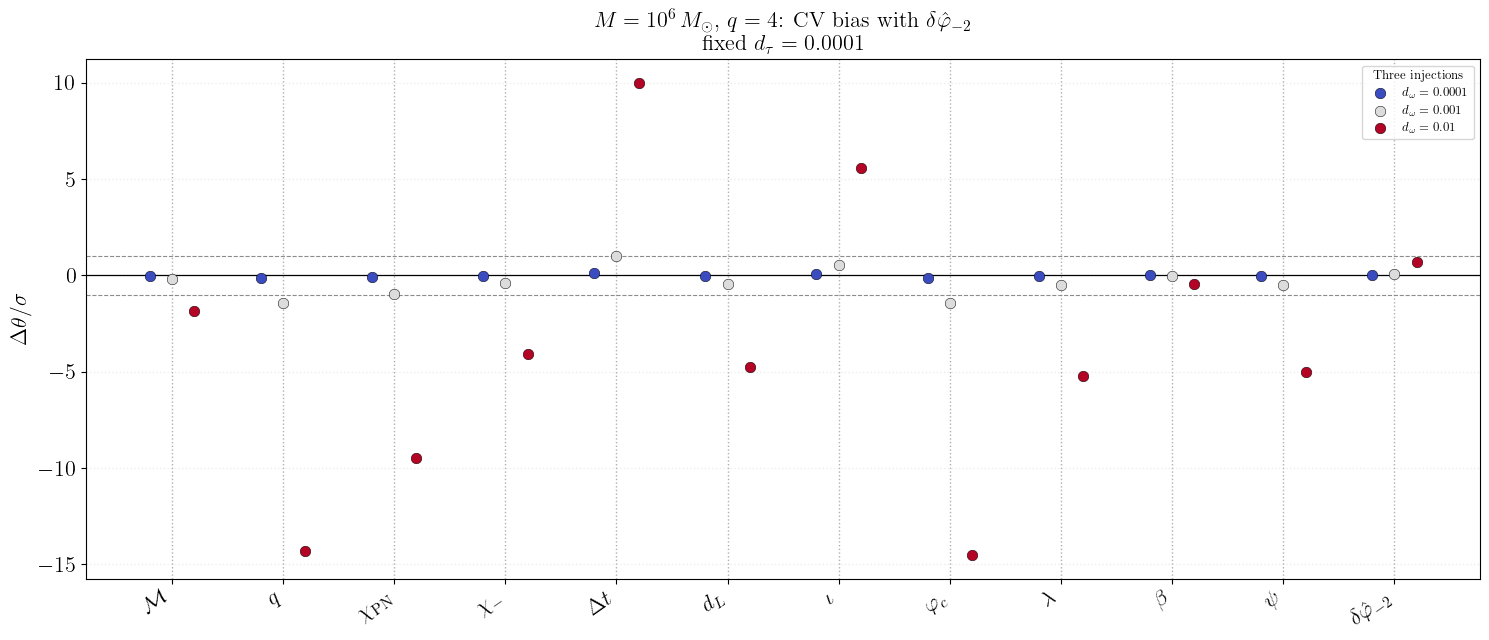

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi0v.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi0v.pdf


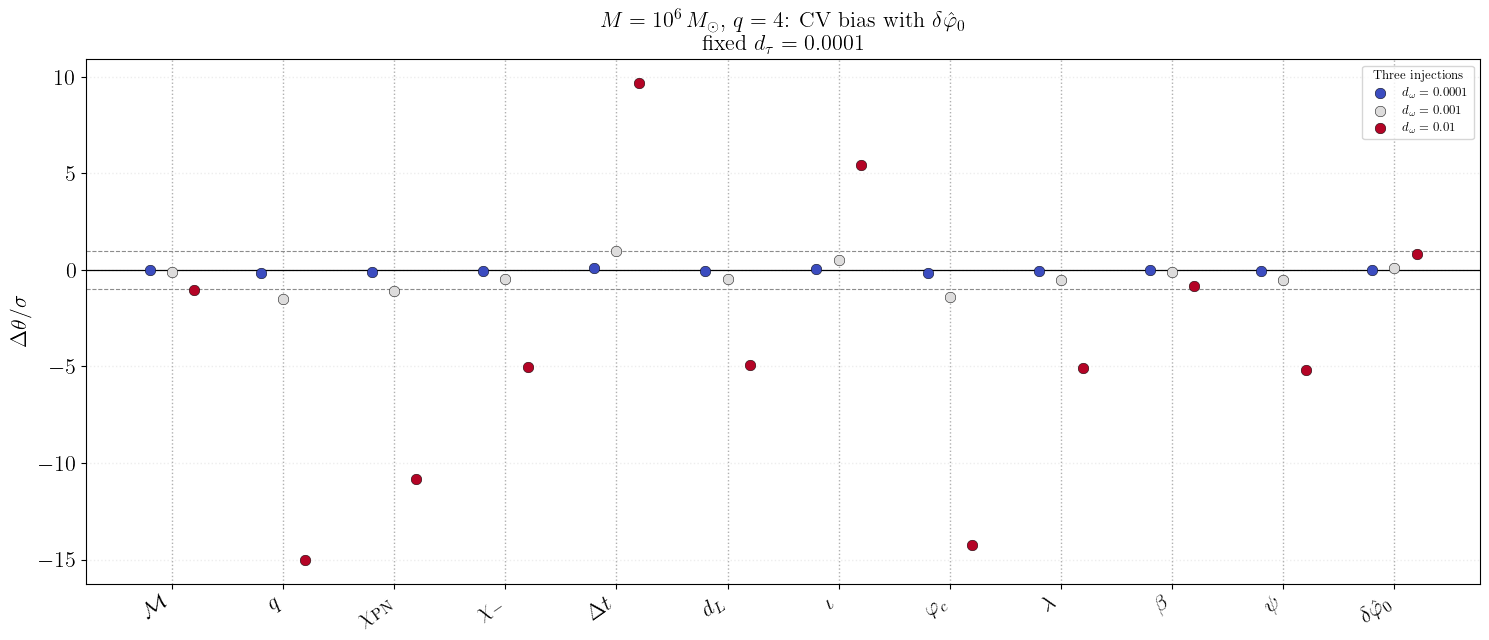

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi1v.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi1v.pdf


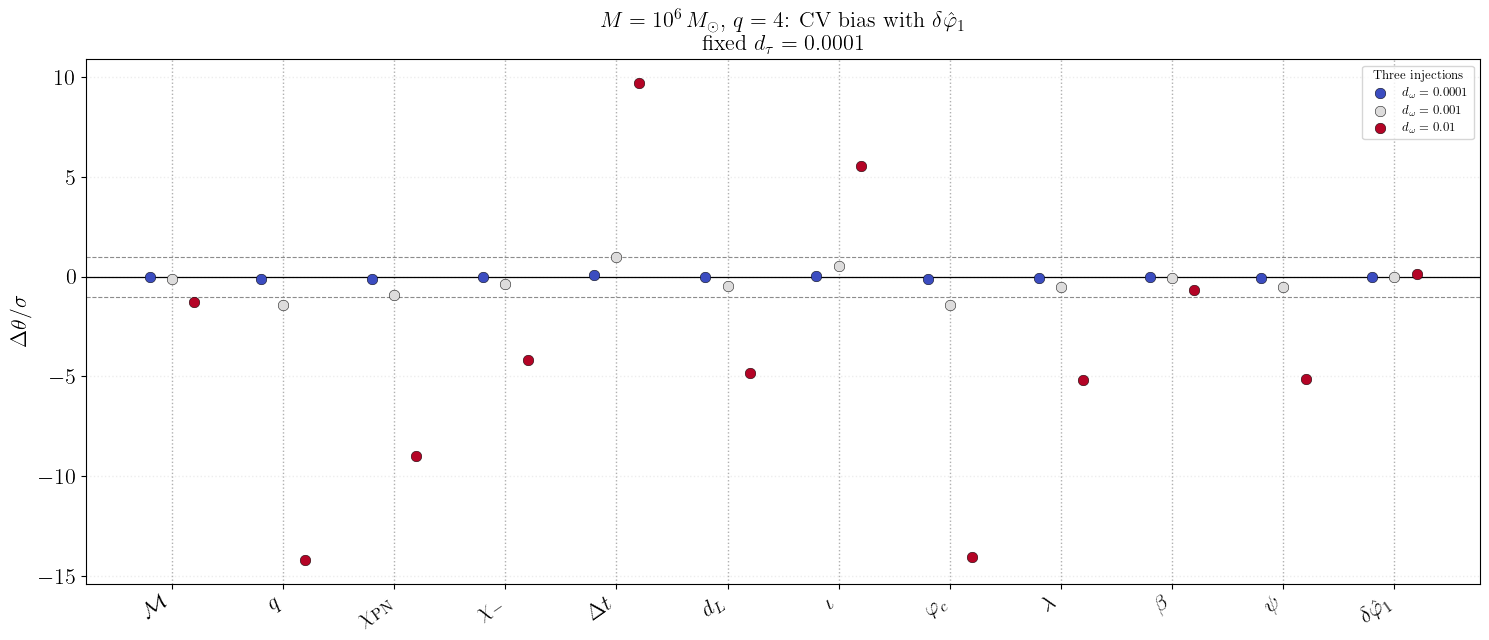

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi2v.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi2v.pdf


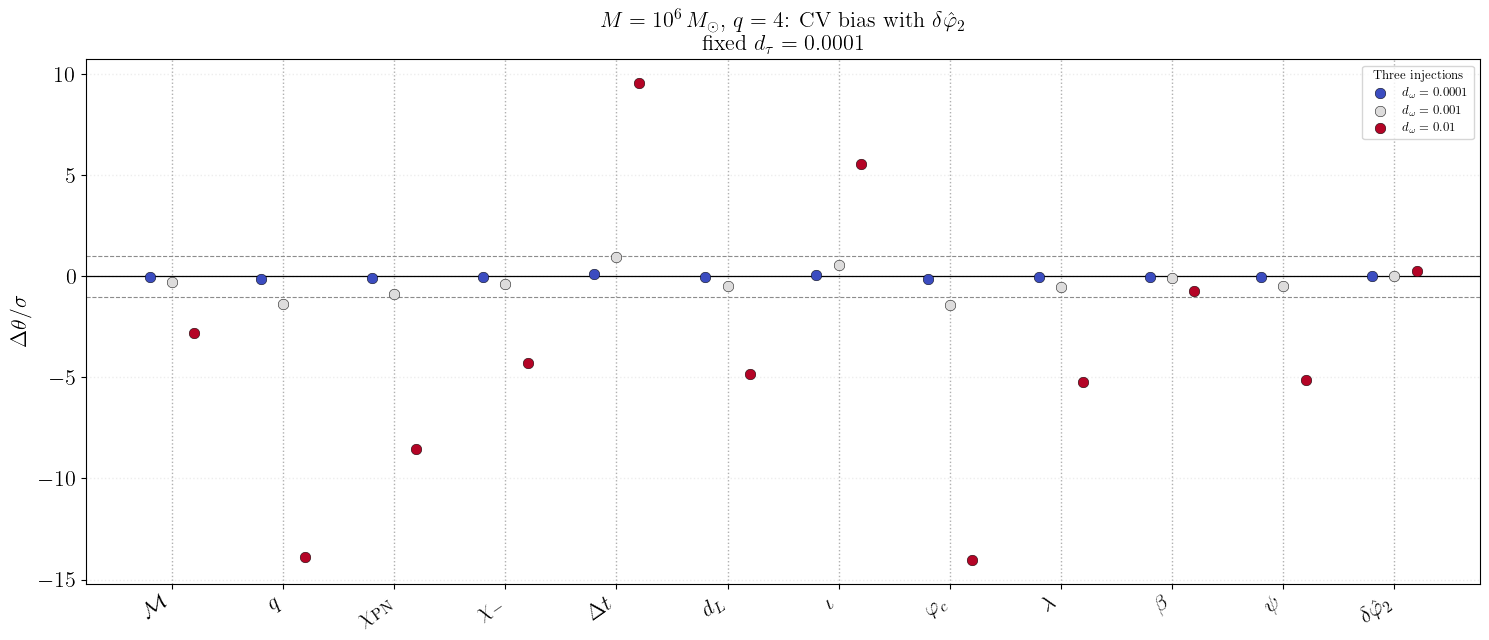

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi3v.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi3v.pdf


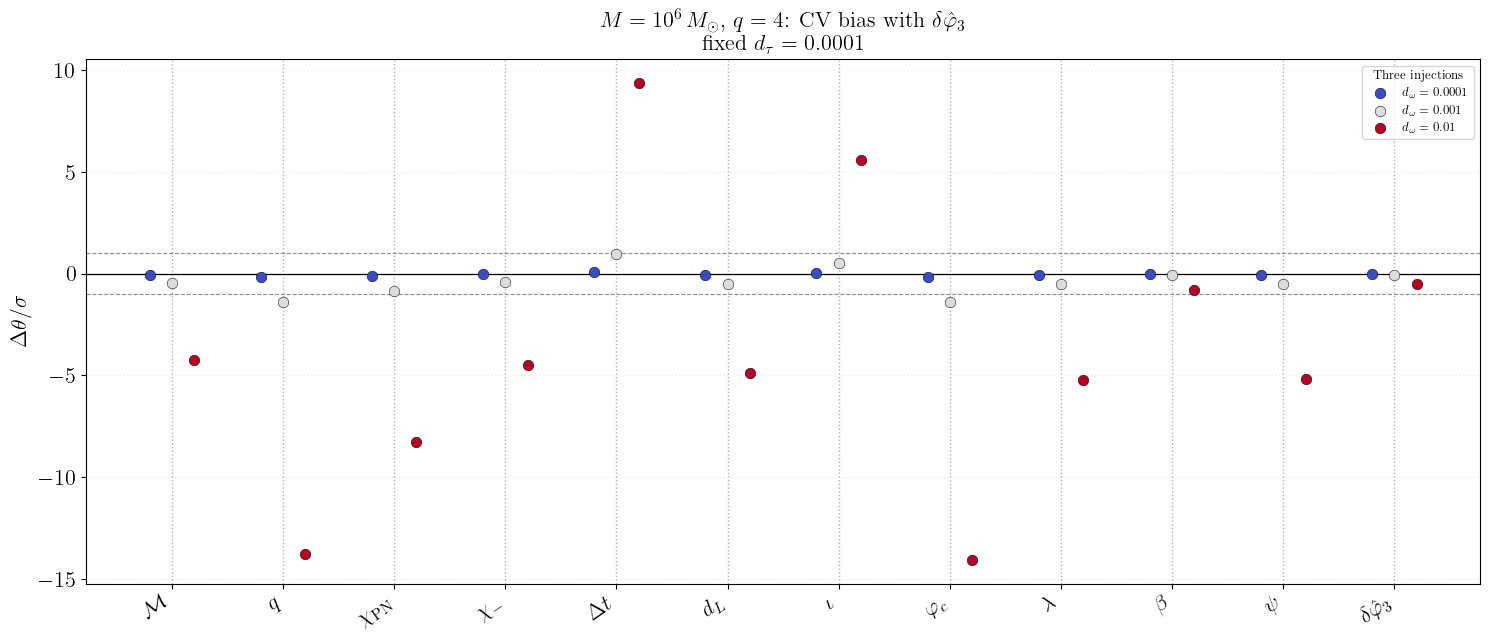

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi4v.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi4v.pdf


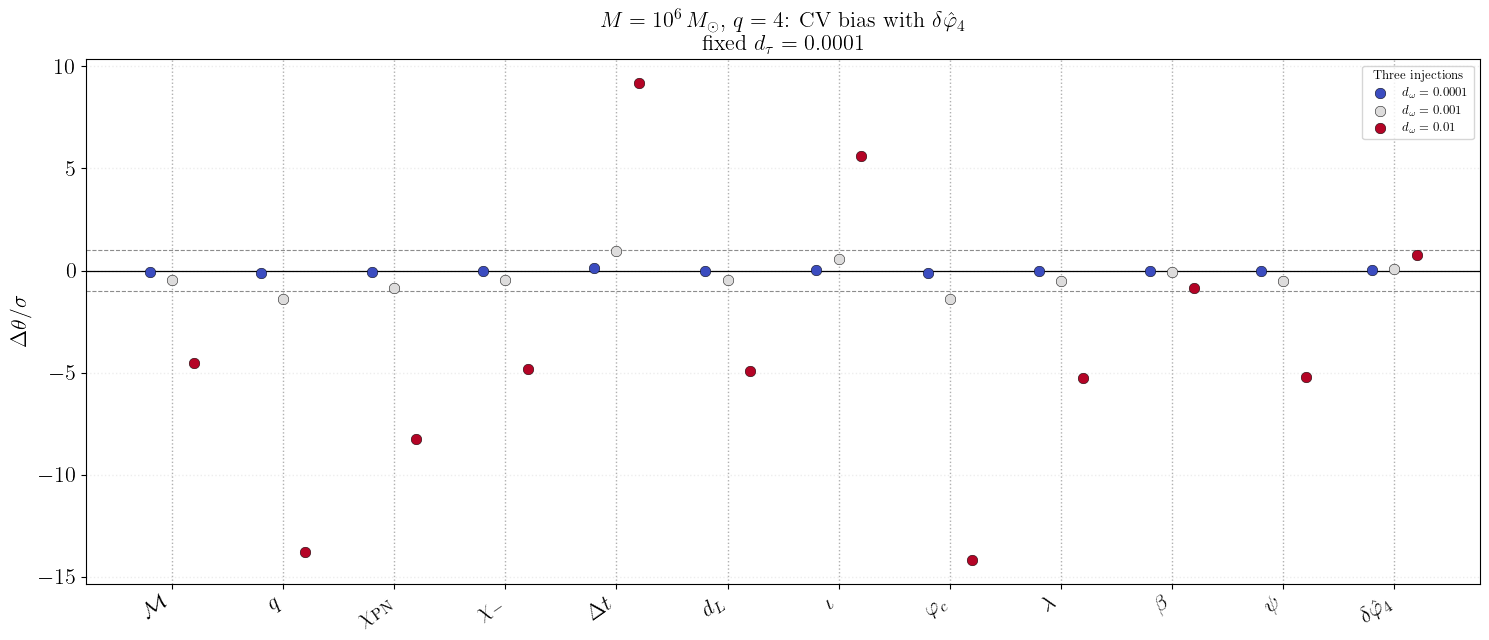

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi5lv.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi5lv.pdf


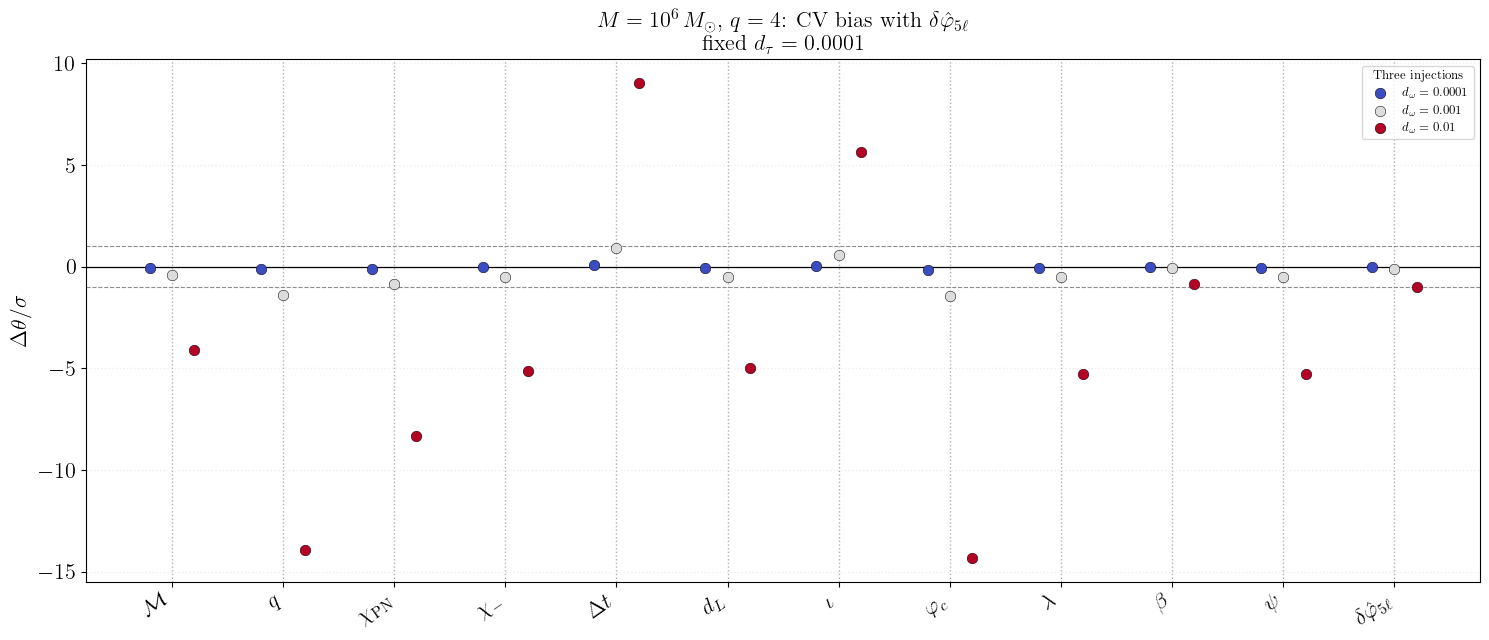

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi6v.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi6v.pdf


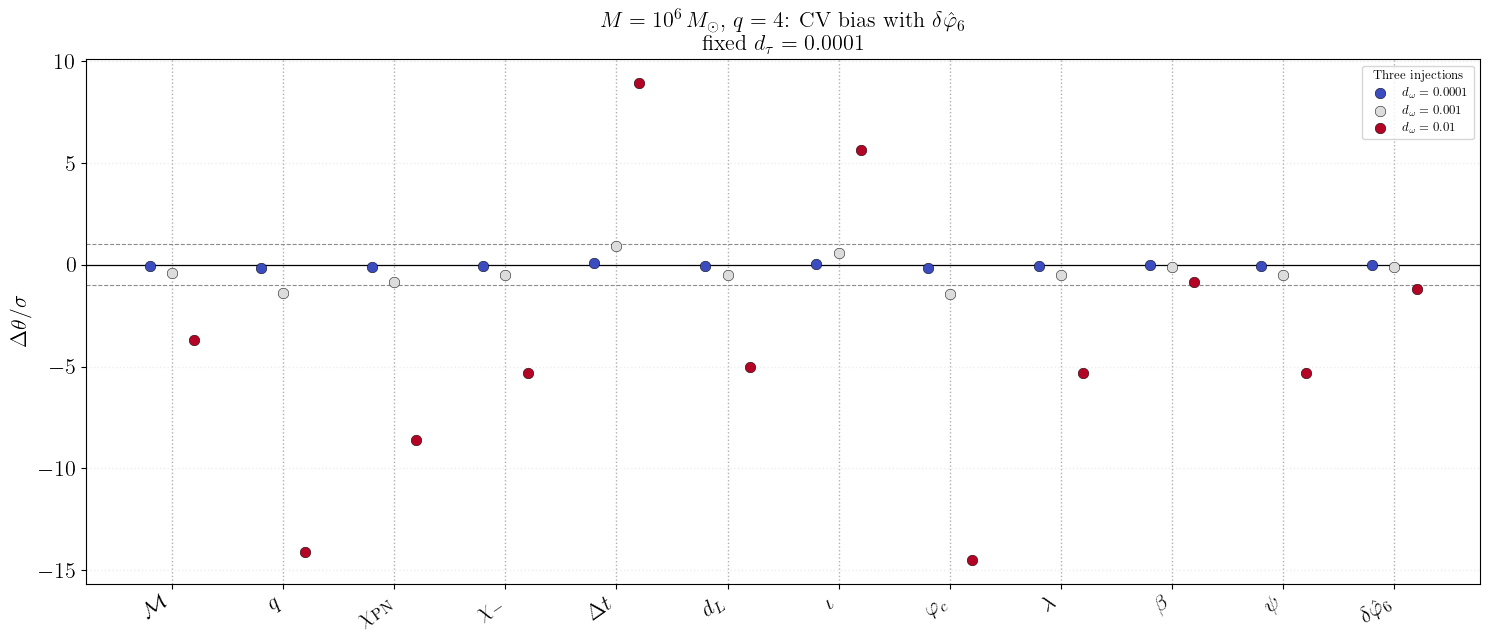

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi6lv.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi6lv.pdf


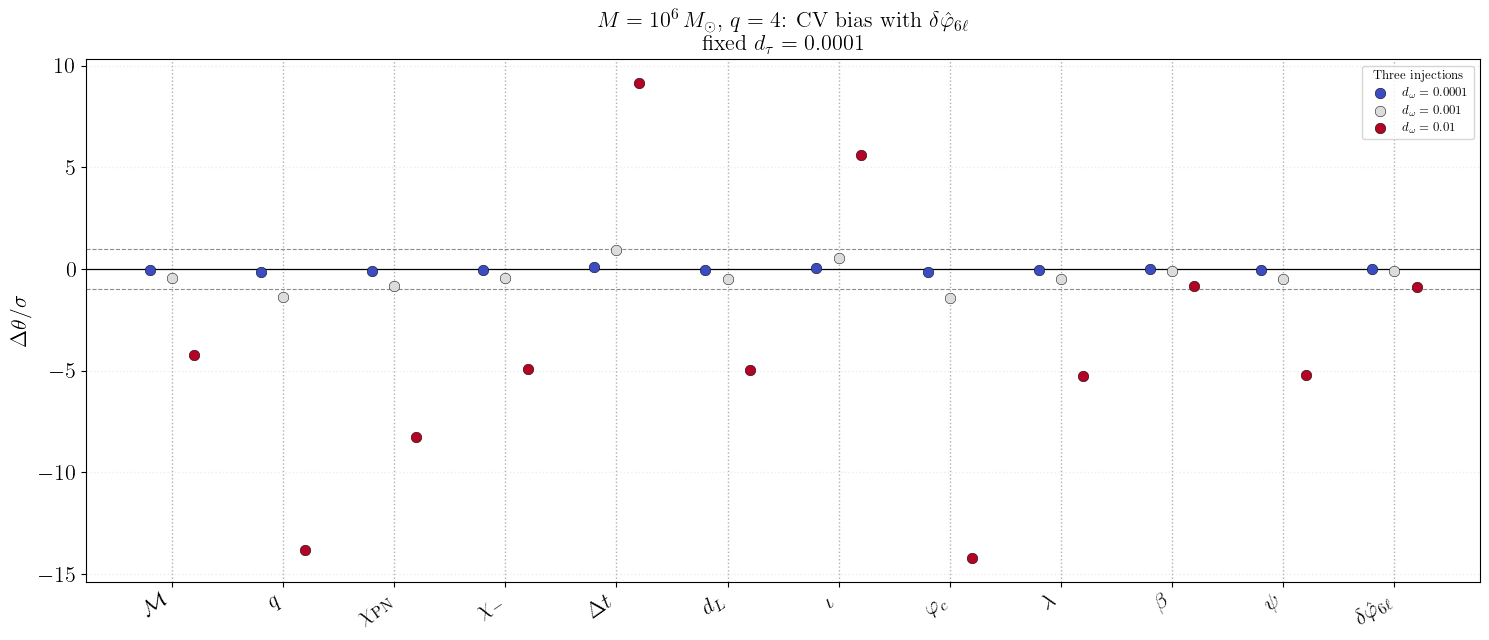

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi7v.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dchi7v.pdf


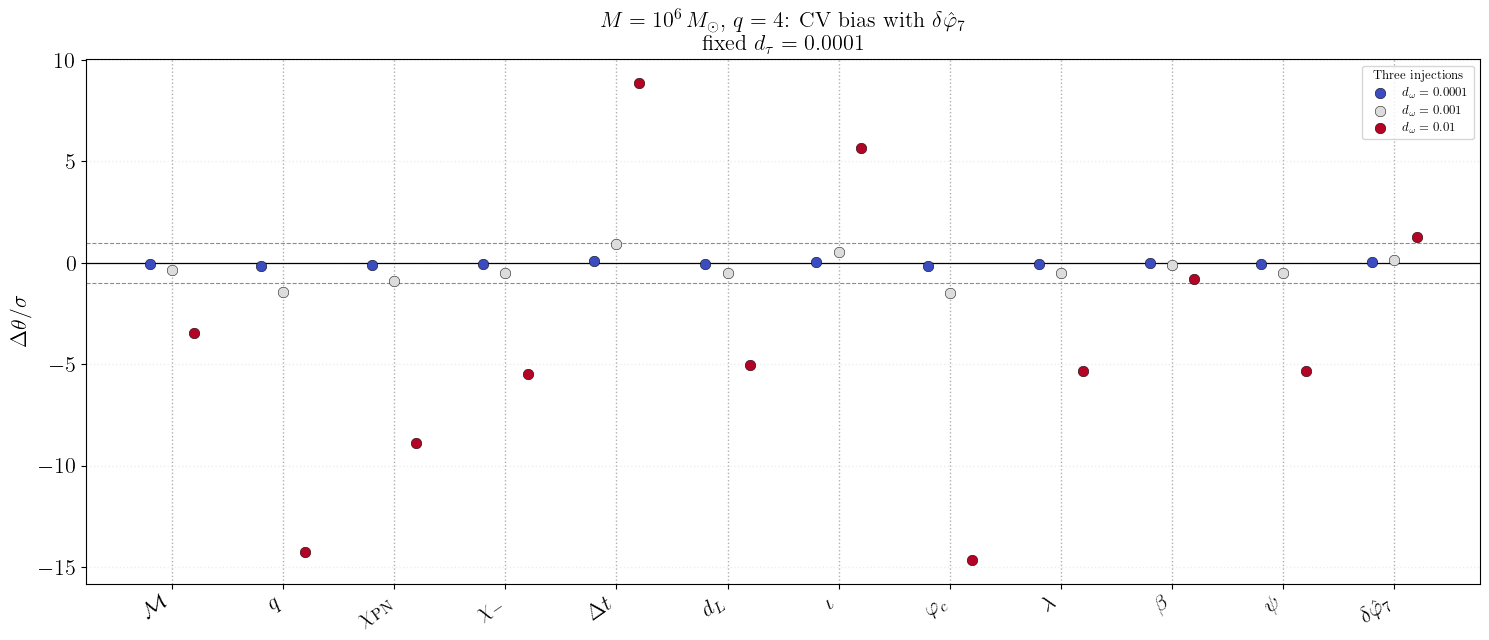

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dkappa_S.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_M1e6_fti_dkappa_S.pdf


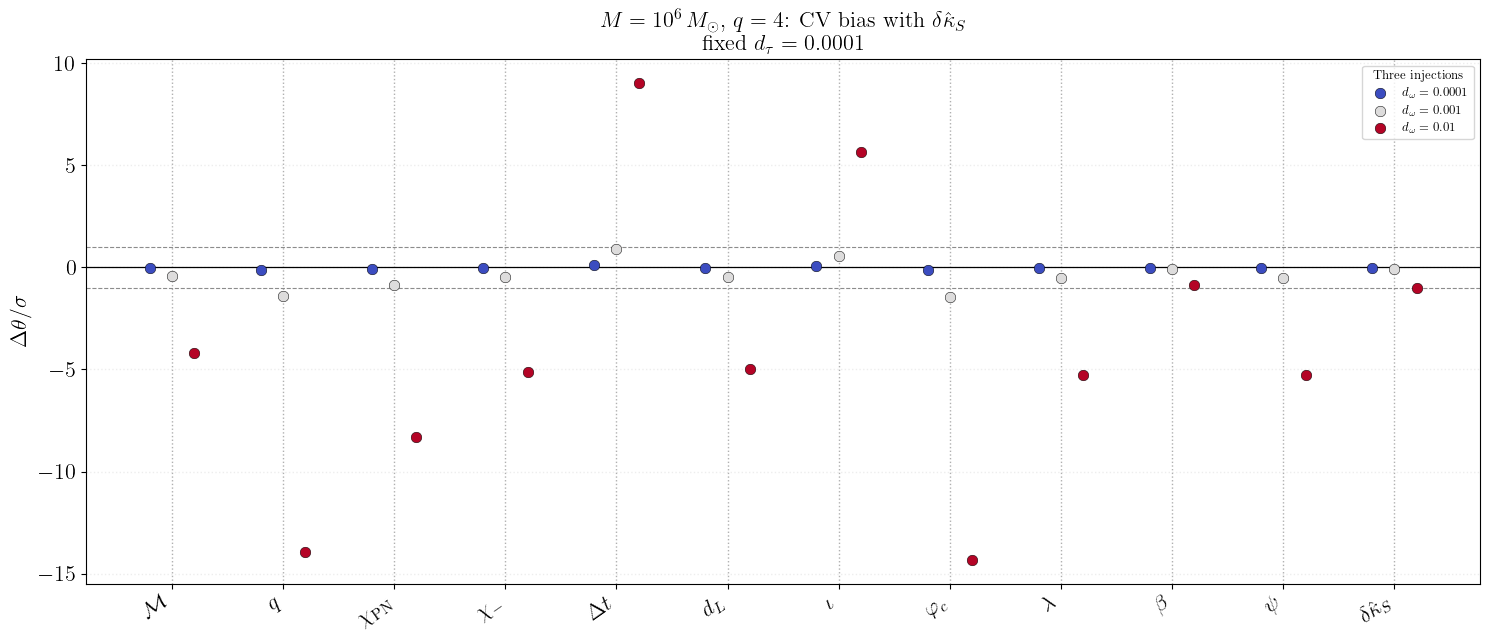

In [14]:

# One figure for each FTI parameter.
# Each physical/recovery parameter has THREE points: one for each QNM-deviation injection.

plt.close("all")

for mass_label, results_by_inj in all_results.items():
    mass_name = MASS_TITLE_BY_LABEL[mass_label]
    figure_dir = os.path.join(get_mass_run_data_dir(mass_label), "cv_bias_figures")

    for fti_param in FTI_PARAMS_TO_SCAN:
        ordered_results = three_results_for_fti(results_by_inj, fti_param)

        plot_params = list(BASE_GR_PARAM) + [fti_param]
        x = np.arange(len(plot_params), dtype=float)

        fig, ax = plt.subplots(figsize=(15, 6.5))

        for offset, (deviation_value, inj_id, result) in zip(
            POINT_OFFSETS, ordered_results
        ):
            y = np.array(
                [result["cv_bias_sigma"][param] for param in plot_params],
                dtype=float,
            )

            color = PLOT_CMAP(PLOT_NORM(deviation_value))
            ax.scatter(
                x + offset,
                y,
                s=58,
                color=color,
                edgecolor="black",
                linewidth=0.35,
                label=scan_value_label(deviation_value),
                zorder=3,
            )

        ax.axhline(0.0, color="black", linewidth=0.9)
        ax.axhline(1.0, color="0.55", linewidth=0.8, linestyle="--")
        ax.axhline(-1.0, color="0.55", linewidth=0.8, linestyle="--")

        ax.set_xticks(x)
        ax.set_xticklabels(
            latex_param_labels(plot_params),
            rotation=35,
            ha="right",
        )
        ax.set_ylabel(r"$\Delta\theta/\sigma$")
        ax.set_title(
            rf"{mass_name}, $q=4$: CV bias with "
            + latex_param_label(fti_param)
            + "\n"
            + "fixed "
            + FIXED_LABEL
        )
        ax.grid(axis="y", alpha=0.22)
        ax.legend(
            title="Three injections",
            frameon=True,
            fontsize=9,
            title_fontsize=9,
        )

        fig.tight_layout()
        save_figure(
            fig,
            figure_dir,
            f"cv_bias_three_points_{mass_label}_{fti_param}",
        )
        plt.show()
        plt.close(fig)


## All 11 FTI parameters together

The final figure keeps only the bias of the active FTI parameter from each
single-FTI recovery case. Thus every FTI parameter has exactly three points,
one from each QNM-deviation injection.

Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_all_11_FTI_M1e6.png
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_dtau_fixed_0p01_domega_scan_M1e6_q4_3points/run_data/bias_syst_recovery/M1e6/cv_bias_figures/cv_bias_three_points_all_11_FTI_M1e6.pdf


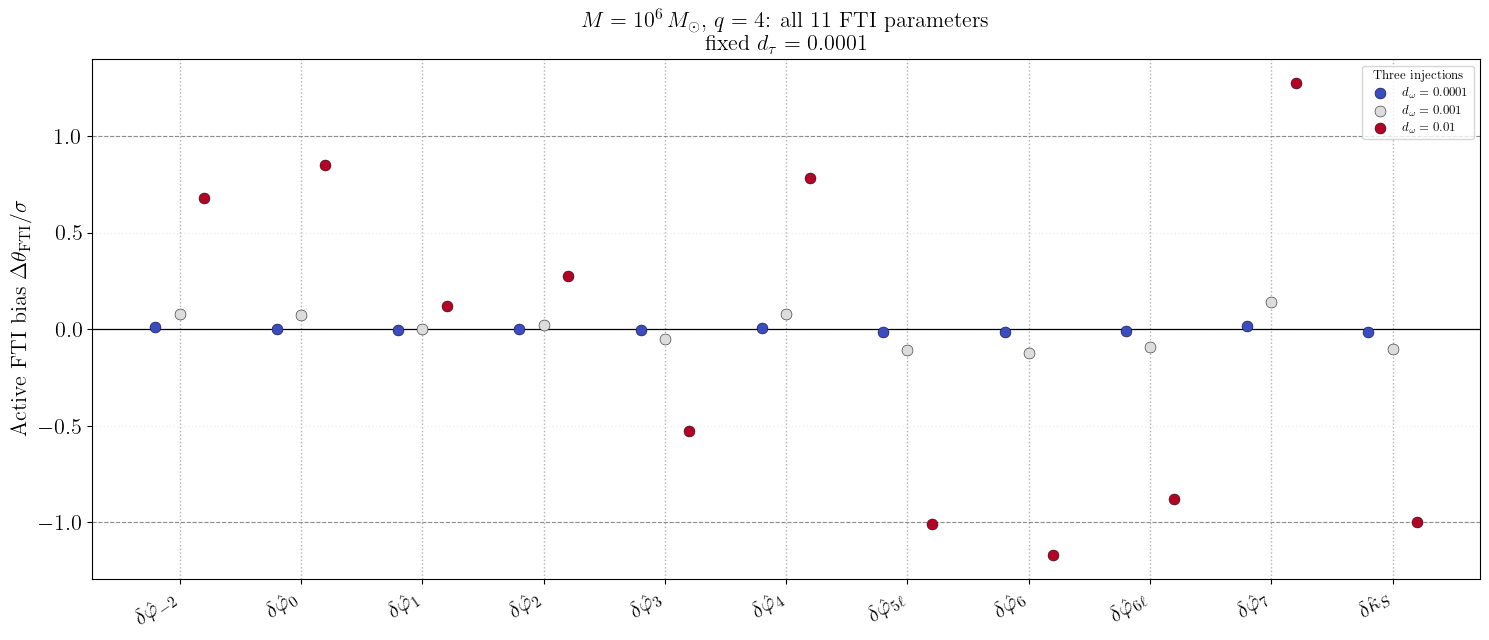

In [15]:

# Final summary: all 11 active FTI biases together.
# Again, THREE points are shown for every FTI parameter.

for mass_label, results_by_inj in all_results.items():
    mass_name = MASS_TITLE_BY_LABEL[mass_label]
    figure_dir = os.path.join(get_mass_run_data_dir(mass_label), "cv_bias_figures")

    x = np.arange(len(FTI_PARAMS_TO_SCAN), dtype=float)
    fig, ax = plt.subplots(figsize=(15, 6.5))

    # Validate the three-point scan using the first FTI case.
    ordered_ids = three_results_for_fti(
        results_by_inj,
        FTI_PARAMS_TO_SCAN[0],
    )

    for offset, (deviation_value, inj_id, _) in zip(
        POINT_OFFSETS, ordered_ids
    ):
        y = []
        for fti_param in FTI_PARAMS_TO_SCAN:
            result = results_by_inj[inj_id].get(fti_param)
            if result is None:
                raise RuntimeError(
                    f"Missing {fti_param} for inj_id={inj_id}."
                )
            if not np.isclose(
                float(result[SCAN_PARAMETER]),
                deviation_value,
                rtol=1e-12,
                atol=0.0,
            ):
                raise RuntimeError(
                    f"Inconsistent {SCAN_PARAMETER} for inj_id={inj_id}, "
                    f"{fti_param}."
                )
            y.append(result["cv_bias_sigma"][fti_param])

        color = PLOT_CMAP(PLOT_NORM(deviation_value))
        ax.scatter(
            x + offset,
            np.asarray(y, dtype=float),
            s=62,
            color=color,
            edgecolor="black",
            linewidth=0.35,
            label=scan_value_label(deviation_value),
            zorder=3,
        )

    ax.axhline(0.0, color="black", linewidth=0.9)
    ax.axhline(1.0, color="0.55", linewidth=0.8, linestyle="--")
    ax.axhline(-1.0, color="0.55", linewidth=0.8, linestyle="--")

    ax.set_xticks(x)
    ax.set_xticklabels(
        latex_param_labels(FTI_PARAMS_TO_SCAN),
        rotation=35,
        ha="right",
    )
    ax.set_ylabel(r"Active FTI bias $\Delta\theta_{\rm FTI}/\sigma$")
    ax.set_title(
        rf"{mass_name}, $q=4$: all 11 FTI parameters"
        + "\n"
        + "fixed "
        + FIXED_LABEL
    )
    ax.grid(axis="y", alpha=0.22)
    ax.legend(
        title="Three injections",
        frameon=True,
        fontsize=9,
        title_fontsize=9,
    )

    fig.tight_layout()
    save_figure(
        fig,
        figure_dir,
        f"cv_bias_three_points_all_11_FTI_{mass_label}",
    )
    plt.show()
    plt.close(fig)
